# Datasets

We have provided several small example datasets for this short course, which have all been preprocessed to be in NetCDF4 format and on a regular latitude-longitude grid. Here, we load all datasets using `xarray` and visualise them using our `quickplot(da)` helper function.

In [1]:
from pathlib import Path

import humanize
import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

In [4]:
DATASET_PATHS = [
    data / "HOAPS" / "HOAPS_2020-08_6-hourly.nc",
    data / "ICON-XPP" / "ICONXPP_regridded_t_025deg_steps_2026-05_06.nc",
    data / "ICON-XPP" / "ICONXPP_regridded_tp_025deg_steps_2026-05_06.nc",
    data / "NextGEMS_EW3_ICON_ngc4008" / "NextGEMS_regridded_hus_025deg_steps_44_45.nc",
    data / "NextGEMS_EW3_ICON_ngc4008" / "NextGEMS_regridded_pr_025deg_steps_44_45.nc",
    data / "OpenIFS" / "OpenIFS_pl_regridded_q_025deg_steps_114_120_levels_100_1000.nc",
    data / "OpenIFS" / "OpenIFS_sfc_regridded_t_025deg_steps_114_120.nc",
    data / "OpenIFS" / "OpenIFS_sfc_regridded_tp_025deg_steps_114_120.nc",
    data / "hplp" / "hplp_ml_regridded_q_025deg_levels_10_137_steps_228_240.nc",
    data / "hplp" / "hplp_sfc_regridded_t_025deg_steps_228_240.nc",
    data / "hplp" / "hplp_sfc_regridded_tp_025deg_steps_228_240.nc",
]

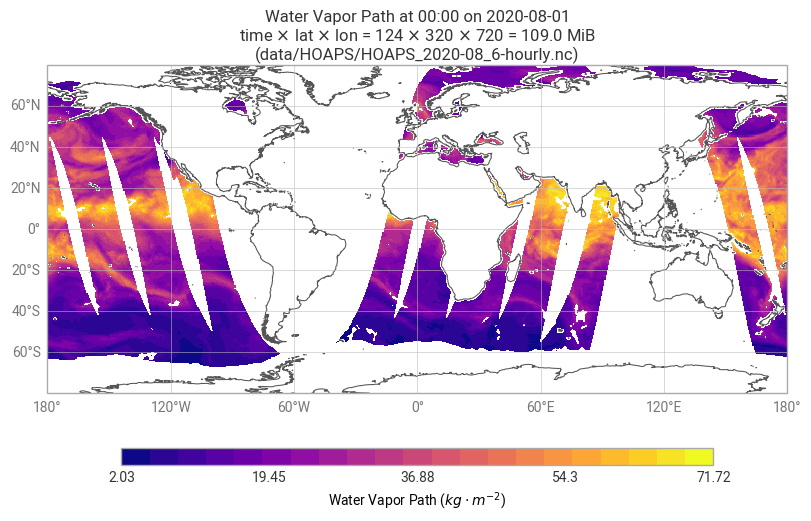

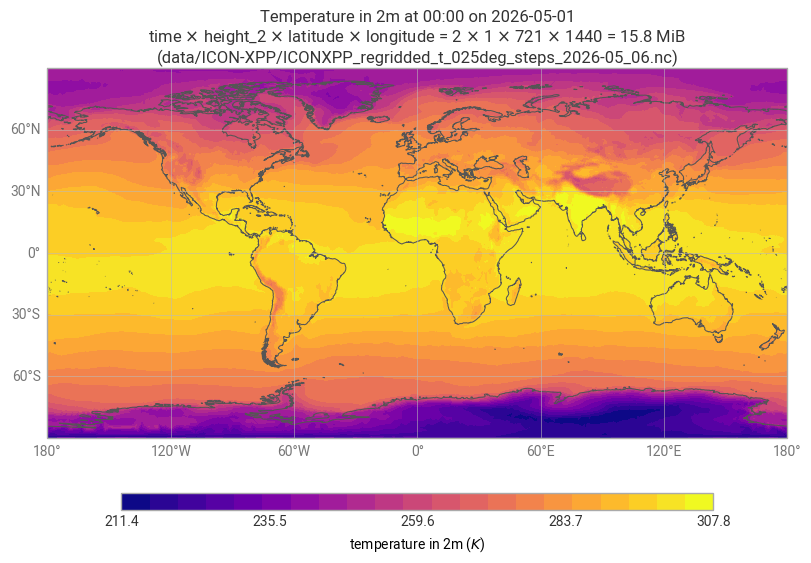

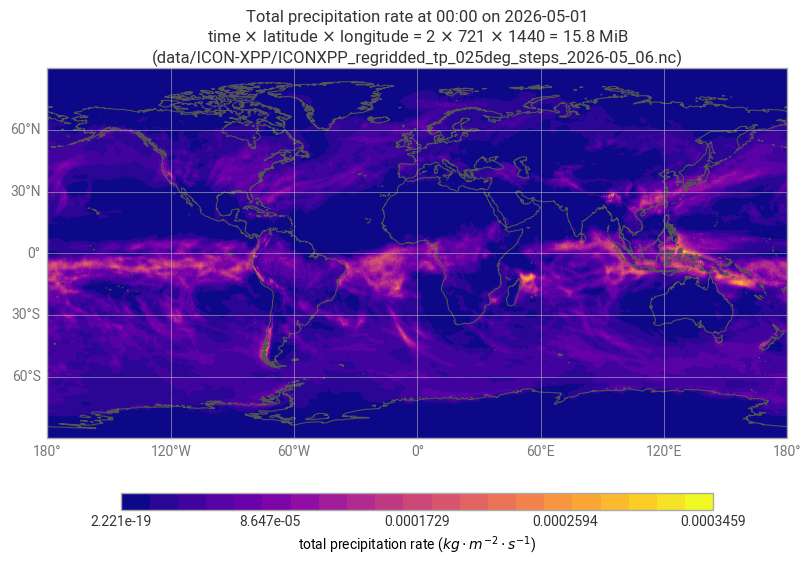

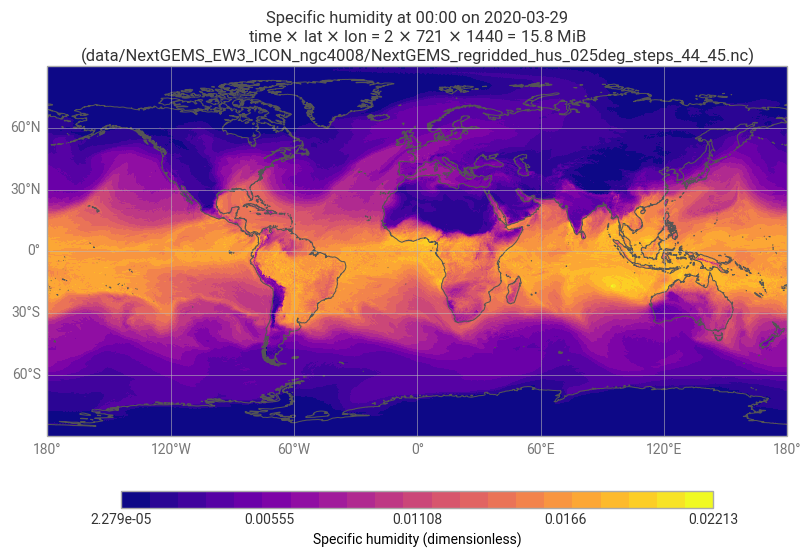

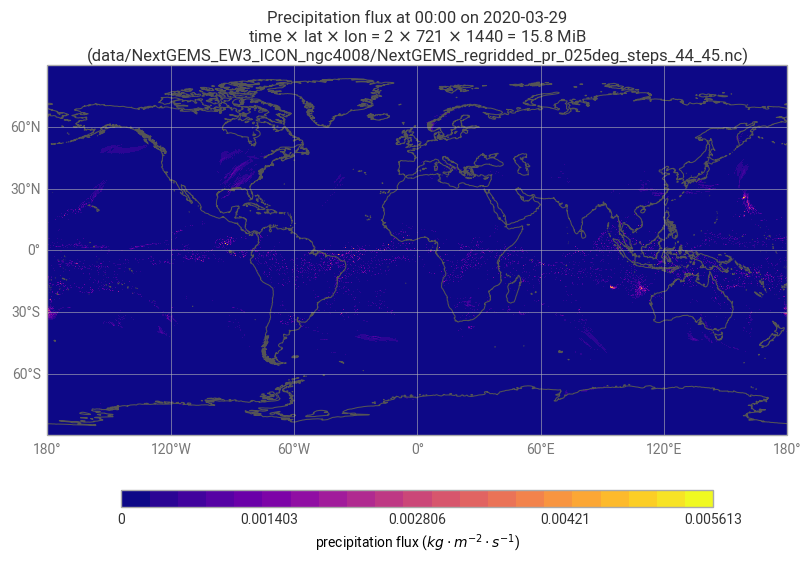

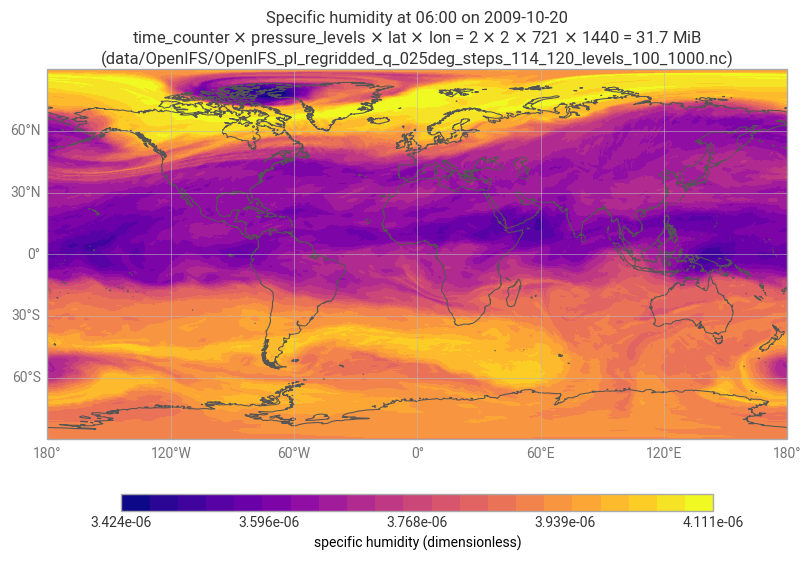

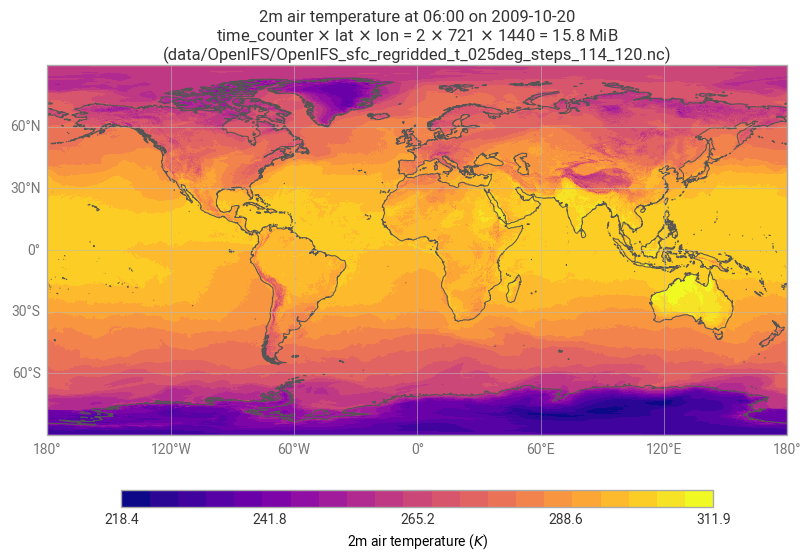

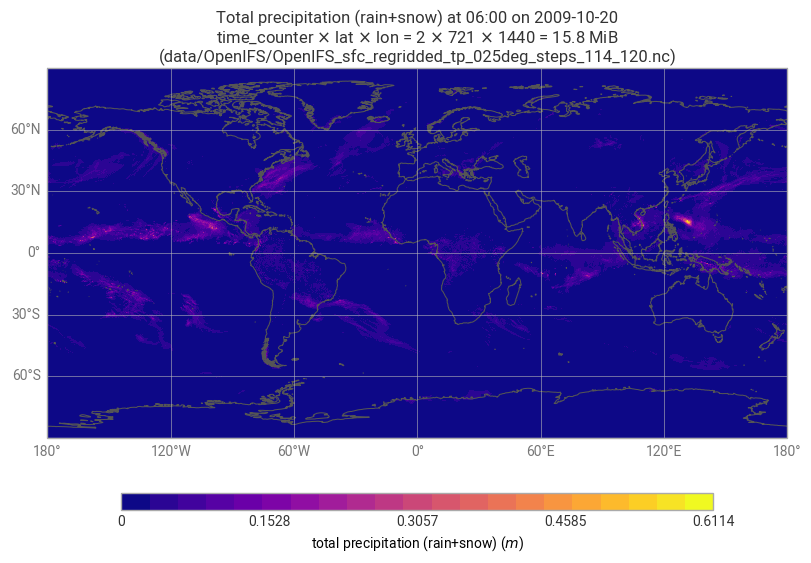

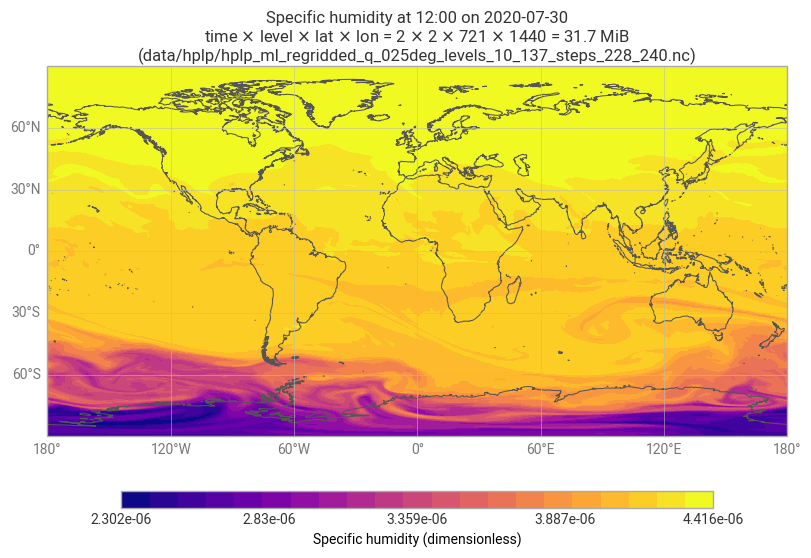

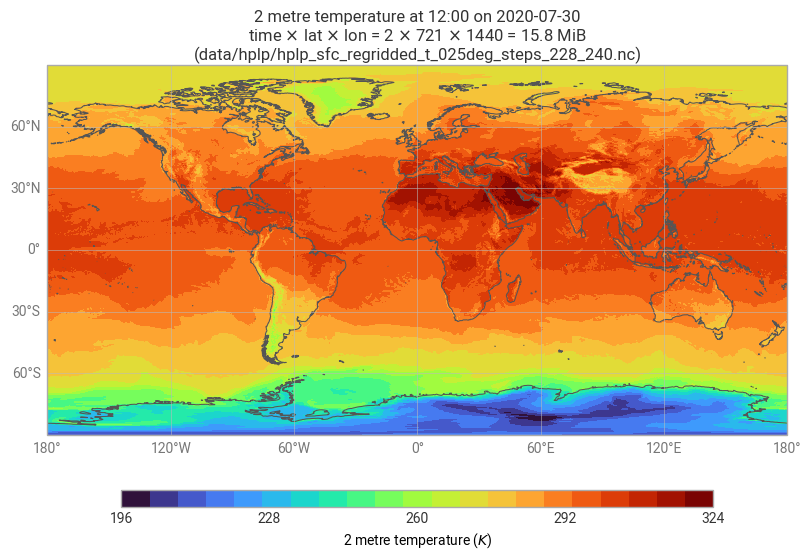

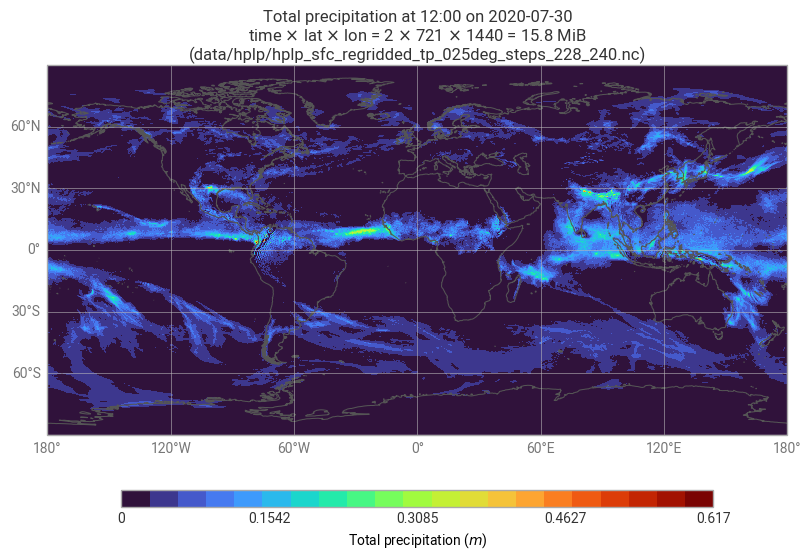

In [5]:
for path in DATASET_PATHS:
    # all example datasets are regridded to regular latitude-longitude grids in NetCDF4 format
    ds = xr.open_dataset(path, engine="netcdf4", decode_timedelta=True)
    # most example datasets only contain a single variable
    if "HOAPS" in path.parent.name == "HOAPS":
        var = "wvpa"
    else:
        (var,) = list(ds)
    da = ds[var]

    quickplot(
        da,
        title=(
            "{default_title}"
            + (
                f"\n{r' $\times$ '.join(da.dims)} = "
                + f"{r' $\times$ '.join(str(s) for s in da.shape)} = "
                + f"{humanize.naturalsize(da.nbytes, binary=True)}"
            )
            + f"\n({path})"
        ),
    )